In [1]:
import torch
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, ViTImageProcessor, BertTokenizer, VisionEncoderDecoderModel

import torch
from torch.utils.data import Dataset
import os
import cv2
import numpy as np

from PIL import Image, ImageFile
from tqdm import tqdm
import xml.etree.ElementTree as ET


import re

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from plant_dataset import load_sideview_images
from image_process import process_leaf_image
from plant_tokenizer import vec2token, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, VOCAB_SIZE
from string_to_xml_to_vec import xml2vec, linked_to_recursive
from plant_dataset import PlantDataset


device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"

Quantize Paramter in 199 levels


In [2]:
from models.model import PlantArchitectureModel, PlantArchitectureConfig
from transformers import VisionEncoderDecoderModel, BertConfig, BertModel, ViTModel, AutoConfig, GPT2Config, AutoImageProcessor

# 1. Define decoder configuration
decoder_checkpoint = "gpt2-medium"
decoder_config = GPT2Config.from_pretrained(decoder_checkpoint)
decoder_config.max_position_embeddings = 4096*2 # Set maximum sequence length
decoder_config.vocab_size = VOCAB_SIZE  # Match with tokenizer's vocabulary size
decoder_config.add_cross_attention=True
decoder_config.is_decoder=True

encoder_checkpoint = "facebook/dinov2-small"
image_size = 448
encoder_config = AutoConfig.from_pretrained(encoder_checkpoint)
if 0:
    image_processor = AutoImageProcessor.from_pretrained(encoder_checkpoint)
    image_processor.crop_size['width'] = image_size
    image_processor.crop_size['height'] = image_size
    image_processor.size['shortest_edge'] = image_size
else:
    image_processor = None

model = PlantArchitectureModel.from_encoder_decoder_pretrained(
    encoder_checkpoint, decoder_checkpoint, 
    decoder_config=decoder_config, 
    encoder_config=encoder_config,
    decoder_ignore_mismatched_sizes=True,
    use_depth=True,
    torch_dtype=torch.float16, 
)

Quantize Paramter in 199 levels


Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2-medium and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.

Total 400000 images and plant strings loaded
[132 132 132 132]


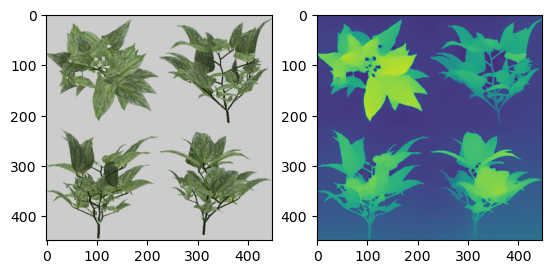

In [10]:
import matplotlib.pyplot as plt

dataset_path = "/home/lion397/datasets/GEMINI/plant_architecture/20250311_Sideview_40Days"

dataset = PlantDataset(root_dir=dataset_path, 
                       process_leaf=True, image_size=image_size,
                       side_view=True,
                       mode='train',
                       preload=False, add_sos_token=False,
                       flip_test=True)
   
ind = 20
pixel_values = dataset[ind]["pixel_values"].unsqueeze(0).to(model.device)
plant_info = dataset[ind]["plant_info"]
plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens

image_vis = pixel_values.squeeze().permute(1,2,0).cpu().numpy()
# image_vis = cv2.cvtColor(image_vis,cv2.COLOR_RGB2BGR)
# image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(image_vis)

depth = model.estimate_depth(pixel_values)
# generated_ids = model.generate(pixel_values,
#                             decoder_start_token_id=SOS_TOKEN,
#                             decoder_input_ids=plant_info,
#                             eos_token_id=EOS_TOKEN,
#                             pad_token_id=PAD_TOKEN,
#                             max_length=2500
#                             )
# print(generated_ids)
depth_vis = depth[0,0,:,:].cpu().numpy()
plt.subplot(1,2,2)
plt.imshow(depth_vis)

# Test run
with torch.no_grad():
    result = model.generate(pixel_values,
                            decoder_start_token_id=SOS_TOKEN,
                            decoder_input_ids=plant_info,
                            eos_token_id=EOS_TOKEN,
                            pad_token_id=PAD_TOKEN,
                            # do_sample=True,
                            # num_beams=5,
                            max_length=10,
                            use_cache=True
                            )
    result = result.squeeze().cpu().numpy()[6:]

print(result)

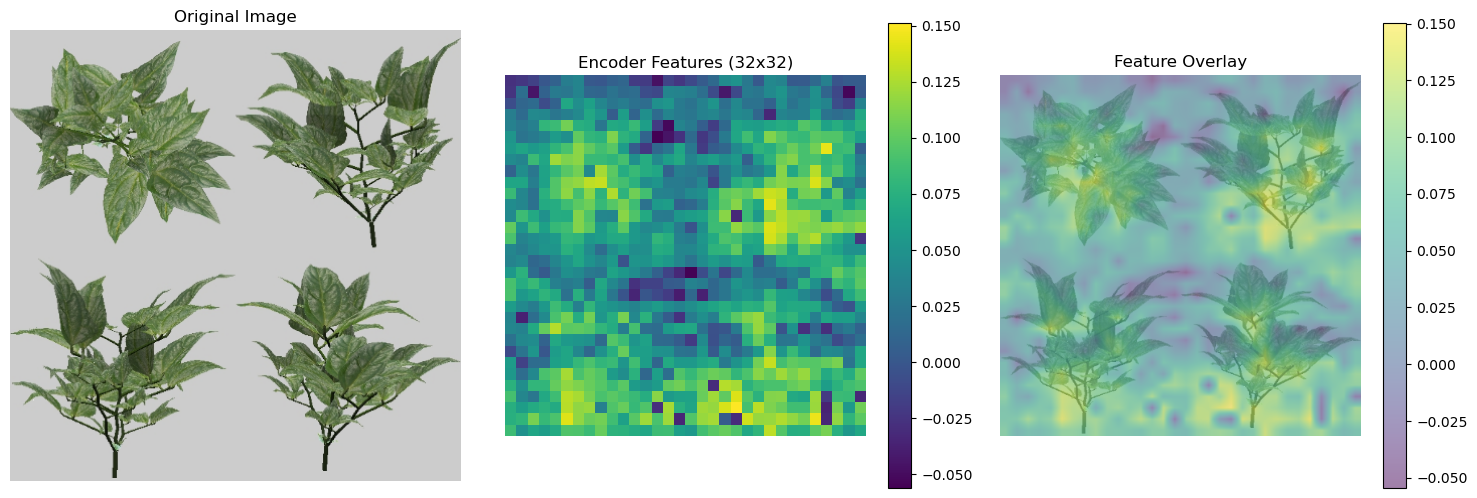

Encoder output shape: torch.Size([1, 1025, 384])
Number of patches: 32x32
Feature dimension: 384
Feature map range: [-0.056, 0.151]


In [44]:
image_processor = AutoImageProcessor.from_pretrained(encoder_checkpoint)
image_processor.crop_size['width'] = image_size
image_processor.crop_size['height'] = image_size
image_processor.size['shortest_edge'] = image_size

# Extract encoder features and visualize them
with torch.no_grad():
    # Get encoder outputs
    if 1:
        input_image = image_processor(pixel_values, return_tensors="pt").pixel_values
        encoder_outputs = model.encoder(input_image)
    else:
        depth = model.estimate_depth(pixel_values)
        encoder_outputs = model.encoder(depth)
    encoder_features = encoder_outputs.last_hidden_state  # Shape: [batch_size, seq_len, hidden_dim]
    
    # Remove batch dimension and get patch features (excluding CLS token if present)
    features = encoder_features.squeeze(0)  # Shape: [seq_len, hidden_dim]
    
    # For ViT models, the sequence includes patch tokens and possibly a CLS token
    # Typically the last token is CLS, so we exclude it
    patch_features = features[:-1]  # Exclude CLS token, Shape: [num_patches, hidden_dim]
    
    # Calculate number of patches per dimension
    num_patches = int(np.sqrt(patch_features.shape[0]))
    
    # Aggregate features across the hidden dimension (mean, max, or specific channels)
    # Option 1: Mean across all feature dimensions
    feature_map = patch_features.mean(dim=1)  # Shape: [num_patches]
    
    # Option 2: Use first few feature dimensions
    # feature_map = patch_features[:, :3].mean(dim=1)  # Use first 3 dimensions
    
    # Reshape to spatial dimensions
    feature_map = feature_map.reshape(num_patches, num_patches).cpu().numpy()
    
    # Resize to match input image size for overlay
    feature_map_resized = cv2.resize(feature_map, (image_vis.shape[1], image_vis.shape[0]))

# Visualize the features
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(image_vis[:,:,:3])  # Show RGB channels only
plt.title("Original Image")
plt.axis('off')

# Feature map
plt.subplot(1, 3, 2)
plt.imshow(feature_map, cmap='viridis')
plt.title(f"Encoder Features ({num_patches}x{num_patches})")
plt.colorbar()
plt.axis('off')

# Overlay feature map on original image
plt.subplot(1, 3, 3)
plt.imshow(image_vis[:,:,:3], alpha=0.7)
plt.imshow(feature_map_resized, alpha=0.5, cmap='viridis')
plt.title("Feature Overlay")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

# Print feature statistics
print(f"Encoder output shape: {encoder_features.shape}")
print(f"Number of patches: {num_patches}x{num_patches}")
print(f"Feature dimension: {patch_features.shape[1]}")
print(f"Feature map range: [{feature_map.min():.3f}, {feature_map.max():.3f}]")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


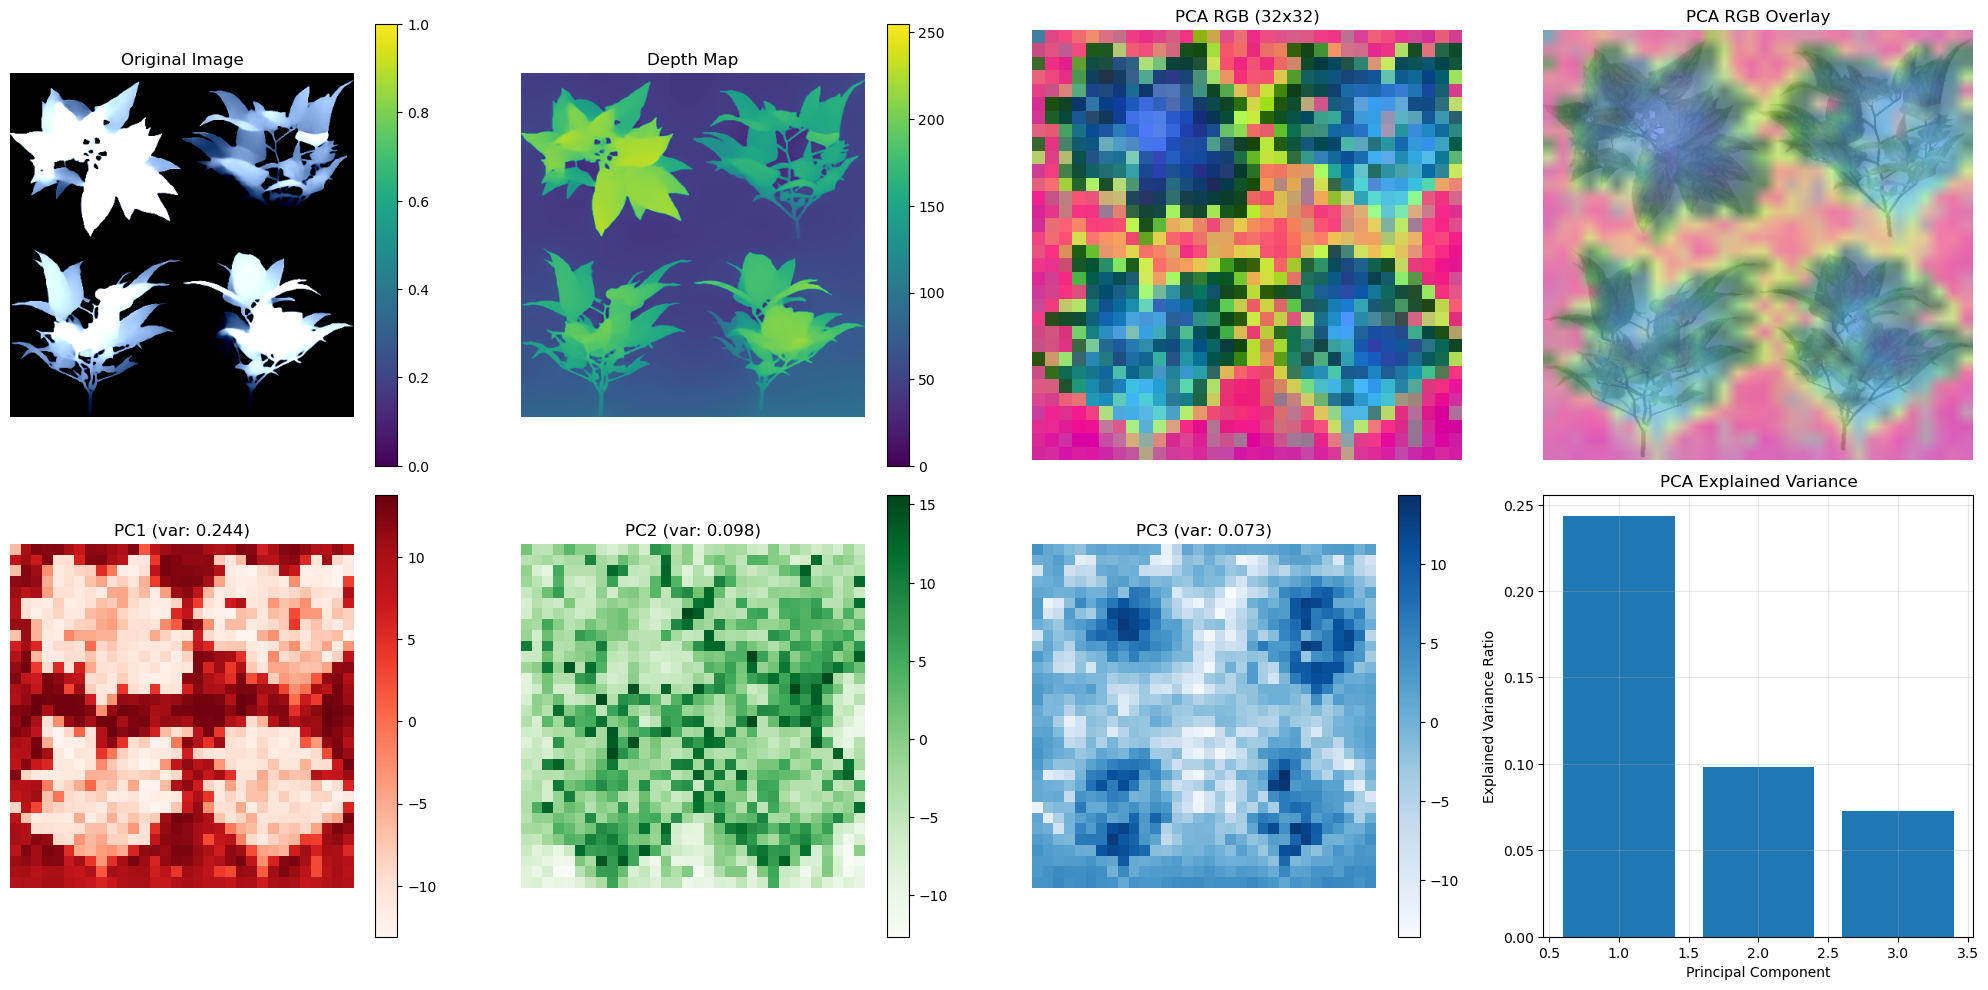

Original feature dimension: 384
PCA explained variance ratio: [0.24360076 0.09848817 0.07263398]
Total variance explained: 0.415
PCA components shape: (1024, 3)
PCA RGB range: R[0.000, 1.000], G[0.000, 1.000], B[0.000, 1.000]


In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Run PCA on encoder features
with torch.no_grad():
    # Get encoder outputs (using the same logic as above)
    if 0:
        if 1:
            input_image = image_processor(pixel_values, return_tensors="pt").pixel_values
        else:
            input_image = pixel_values
    else:
        depth = model.estimate_depth(pixel_values)
        depth = depth.cpu().numpy().astype(np.uint8)
        if 1:
            
            input_image = image_processor(depth, return_tensors="pt").pixel_values
        else:
            input_image = depth
            
    encoder_outputs = model.encoder(input_image)

    encoder_features = encoder_outputs.last_hidden_state  # Shape: [batch_size, seq_len, hidden_dim]
    
    # Remove batch dimension and get patch features (excluding CLS token if present)
    features = encoder_features.squeeze(0)  # Shape: [seq_len, hidden_dim]
    patch_features = features[:-1]  # Exclude CLS token, Shape: [num_patches, hidden_dim]
    
    # Calculate number of patches per dimension
    num_patches = int(np.sqrt(patch_features.shape[0]))
    
    # Convert to numpy for PCA
    features_np = patch_features.cpu().numpy()  # Shape: [num_patches, hidden_dim]
    
    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_np)
    
    # Apply PCA
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(features_scaled)  # Shape: [num_patches, 3]
    
    # Normalize PCA components to [0, 1] for RGB visualization
    pca_rgb = np.zeros_like(pca_features)
    for i in range(3):
        pca_rgb[:, i] = (pca_features[:, i] - pca_features[:, i].min()) / (pca_features[:, i].max() - pca_features[:, i].min())
    
    # Reshape to spatial dimensions
    pca_rgb_map = pca_rgb.reshape(num_patches, num_patches, 3)
    
    # Resize to match input image size
    pca_rgb_resized = cv2.resize(pca_rgb_map, (image_vis.shape[1], image_vis.shape[0]))

# Visualize PCA results
plt.figure(figsize=(20, 10))

# Original image
plt.subplot(2, 4, 1)
plt.imshow(input_image.squeeze().permute(1,2,0), cmap='viridis')
plt.title("Original Image")
plt.colorbar()
plt.axis('off')

# Depth image
plt.subplot(2, 4, 2)
depth_vis = depth[0,0,:,:]
plt.imshow(depth_vis, cmap='viridis')
plt.title("Depth Map")
plt.colorbar()
plt.axis('off')

# PCA RGB visualization
plt.subplot(2, 4, 3)
plt.imshow(pca_rgb_map)
plt.title(f"PCA RGB ({num_patches}x{num_patches})")
plt.axis('off')

# PCA RGB overlay on original image
plt.subplot(2, 4, 4)
plt.imshow(image_vis[:,:,:3], alpha=0.6)
plt.imshow(pca_rgb_resized, alpha=0.6)
plt.title("PCA RGB Overlay")
plt.axis('off')

# Individual PCA components
for i in range(3):
    plt.subplot(2, 4, 5 + i)
    component_map = pca_features[:, i].reshape(num_patches, num_patches)
    plt.imshow(component_map, cmap=['Reds', 'Greens', 'Blues'][i])
    plt.title(f"PC{i+1} (var: {pca.explained_variance_ratio_[i]:.3f})")
    plt.colorbar()
    plt.axis('off')

# PCA explained variance
plt.subplot(2, 4, 8)
plt.bar(range(1, 4), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print PCA statistics
print(f"Original feature dimension: {features_np.shape[1]}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print(f"PCA components shape: {pca_features.shape}")
print(f"PCA RGB range: R[{pca_rgb[:, 0].min():.3f}, {pca_rgb[:, 0].max():.3f}], "
      f"G[{pca_rgb[:, 1].min():.3f}, {pca_rgb[:, 1].max():.3f}], "
      f"B[{pca_rgb[:, 2].min():.3f}, {pca_rgb[:, 2].max():.3f}]")